In [1]:
from utils import *
import math

### Graph I
Our first LangGraph graph!

In [16]:
class AgentState(TypedDict): # Our state schema
    name : str 


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['name'] = state["name"] + ", your'e doing a great job learning Langgraph!"

    return state 

In [17]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

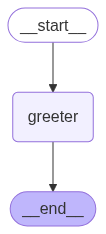

In [18]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({"name": "Sabar"})

In [20]:
result["name"]

"Sabar, your'e doing a great job learning Langgraph!"

### Graph II

In [7]:
class AgentState(TypedDict):
    values: List[int]
    name: str 
    operation: str
    result: str 

In [8]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)

    if state["operation"] == "sum":
        state["result"] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"
    elif state["operation"] == "product":
        state["result"] = f"Hi there {state["name"]}! Your product = {math.prod(state["values"])}"

    print(state)
    return state

In [9]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor") # Set the starting node
graph.set_finish_point("processor") # Set the ending node

app = graph.compile() # Compiling the graph

In [10]:
answers = app.invoke({"values": [1,2,3,4], "operation":"sum" ,"name": "Sabar"})

{'values': [1, 2, 3, 4], 'name': 'Sabar', 'operation': 'sum'}
{'values': [1, 2, 3, 4], 'name': 'Sabar', 'operation': 'sum', 'result': 'Hi there Sabar! Your sum = 10'}


In [11]:
print(answers["result"])

Hi there Sabar! Your sum = 10


In [12]:
answers = app.invoke({"values": [1,2,3,4], "operation":"product" ,"name": "Sabar"})

{'values': [1, 2, 3, 4], 'name': 'Sabar', 'operation': 'product'}
{'values': [1, 2, 3, 4], 'name': 'Sabar', 'operation': 'product', 'result': 'Hi there Sabar! Your product = 24'}


In [13]:
print(answers["result"])

Hi there Sabar! Your product = 24


### Graph III

In [21]:
class AgentState(TypedDict):
    name: str
    age: str
    skills: list[str]
    final: str

In [22]:
def first_node(state:AgentState) -> AgentState:
    """This is the first node of our sequence"""
    print(state)
    state["final"] = f"Hi {state["name"]}!"
    print(state)
    return state

def second_node(state:AgentState) -> AgentState:
    """This is the second node of our sequence"""
    print(state)
    state["final"] = state["final"] + f" You are {state["age"]} years old!"
    print(state)
    return state

def third_node(state:AgentState) -> AgentState:
    """This is the third node of our sequence"""
    print(state)
    state["final"] = state["final"] + f" Your skills are {', '.join(state["skills"])}."
    print(state)
    return state

In [23]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.set_finish_point("third_node")
app = graph.compile()

In [24]:
result = app.invoke({"name": "Sabar", "age": 35, "skills": ["Python", "Langgraph", "AI","GenAI"]})
print(result["final"])

{'name': 'Sabar', 'age': 35, 'skills': ['Python', 'Langgraph', 'AI', 'GenAI']}
{'name': 'Sabar', 'age': 35, 'skills': ['Python', 'Langgraph', 'AI', 'GenAI'], 'final': 'Hi Sabar!'}
{'name': 'Sabar', 'age': 35, 'skills': ['Python', 'Langgraph', 'AI', 'GenAI'], 'final': 'Hi Sabar!'}
{'name': 'Sabar', 'age': 35, 'skills': ['Python', 'Langgraph', 'AI', 'GenAI'], 'final': 'Hi Sabar! You are 35 years old!'}
{'name': 'Sabar', 'age': 35, 'skills': ['Python', 'Langgraph', 'AI', 'GenAI'], 'final': 'Hi Sabar! You are 35 years old!'}
{'name': 'Sabar', 'age': 35, 'skills': ['Python', 'Langgraph', 'AI', 'GenAI'], 'final': 'Hi Sabar! You are 35 years old! Your skills are Python, Langgraph, AI, GenAI.'}
Hi Sabar! You are 35 years old! Your skills are Python, Langgraph, AI, GenAI.
